In [10]:
import torch

#saved = torch.load("../dynamics/chignolin_dynamics_20260305_154302/dynamics_trajectory.pt")
#saved = torch.load("../dynamics/2chf_structure_prediction_20260305_215519/dynamics_trajectory.pt")
saved = torch.load("../dynamics/nug2_folding_sim_20260305_165239/dynamics_trajectory.pt")

print(saved.keys())

dict_keys(['all_pos', 'all_t0', 'args', 'all_scoring_energies', 'native_energy', 'num_resample_rounds', 'cluster_resampling_firstround', 'cluster_resampling_allrounds', 'start_unfolded', 'log_dynamics_energies', 'save_stride'])


In [11]:
diffs = [i for i,x in enumerate(saved['all_pos']) if x.shape[0] != saved['all_pos'][0].shape[0]]
start = min(diffs) if len(diffs) > 0 else 0

nbatch = len(saved['all_pos'][start:])
print(nbatch)

all_pos = torch.stack([x for x in saved['all_pos']][start:]).reshape((nbatch,1) + saved['all_pos'][-1].shape) 
all_t0 = torch.stack([x for x in saved['all_t0']][start:]).reshape((nbatch,1) + saved['all_t0'][-1].shape) 
all_nrgs = torch.stack([x[0] for x in saved['all_scoring_energies']][start:]).view(-1)

1


In [12]:
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa
from protein_ebm.data.protein_utils import residues_to_features, plot_protein_frame, restypes
from protein_ebm.model.boltz_utils import center_random_augmentation

#Load the structure
parser = PDBParser(QUIET=True)
#structure = parser.get_structure("my_structure", "../eval_data/fastfolders/experimental_structures/chignolin_cln025.pdb")
#structure = parser.get_structure("my_structure", "../eval_data/decoys/natives/2chf.pdb")
structure = parser.get_structure("my_structure", "../eval_data/fastfolders/experimental_structures/proteing_1mi0.pdb")


chain = [c for c in structure.get_chains()][0]
atom_positions, atom_mask, aatype, residue_idx = residues_to_features([r for r in chain.get_residues() if is_aa(r)])
nres = atom_positions.shape[0]

sequence = "".join([restypes[a.item()] for a in aatype])

residue_mask = torch.ones(nres) 
aatype = torch.tensor(aatype, dtype=torch.long)
ca_coords = center_random_augmentation(atom_positions[...,1,:].unsqueeze(0), torch.ones([1, nres])).view([1,-1,3])


/tmp/ipykernel_314991/3918153242.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  aatype = torch.tensor(aatype, dtype=torch.long)


In [13]:
plot_protein_frame(atom_positions, atom_mask, cartoon=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [14]:
import numpy as np

def np_rmsd(true, pred):
  def sigmoid(z):
    return 1/(1 + np.exp(-z))
  
  def kabsch(P, Q):
    V, S, W = np.linalg.svd(np.swapaxes(P, -1,-2) @ Q, full_matrices=False)
    flip = sigmoid(-10 * np.linalg.det(V) * np.linalg.det(W))
    S = flip[:,None] * np.concatenate([S[:-1], -S[-1:]]) + (1-flip)[:,None] * S
    V = flip[:, None, None] * np.concatenate([V[:,:-1], -V[:,-1:]], axis=1) + (1-flip)[:, None, None] * V
    return V@W
  p = true - true.mean(1,keepdims=True)
  q = pred - pred.mean(1,keepdims=True)
  p = p @ kabsch(p,q)
  loss = np.sqrt(np.square(p-q).sum(-1).mean(-1) + 1e-8)
  return loss

pred = all_t0.view((-1,) + all_t0.shape[4:])[...,1,:].numpy()
all_rmsd = np_rmsd(pred, ca_coords.numpy())

print("RMSD at lowest energy is", all_rmsd[np.argsort(all_nrgs)[0]])

# all_rmsd2 = np_rmsd(pred, ca_coords2.numpy())
# print("RMSD2 at lowest energy is", all_rmsd2[np.argsort(all_nrgs)[0]])


RMSD at lowest energy is 1.3069562


Text(0, 0.5, 'Model Energy')

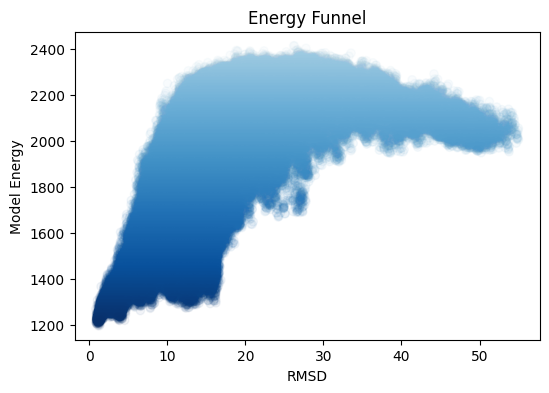

In [16]:
from matplotlib import colors
import matplotlib.pyplot as plt


def truncate_cmap(cmap, minval=0.0, maxval=1.0, n=256):
    """Return a truncated colormap from cmap between minval and maxval (fractions)."""
    cmap = plt.get_cmap(cmap)
    new_colors = cmap(np.linspace(minval, maxval, n))
    return colors.ListedColormap(new_colors)


plt.figure(figsize=(6, 4))
plt.scatter(all_rmsd, all_nrgs.numpy(), alpha=0.05, c=-all_nrgs.numpy(), cmap=truncate_cmap("Blues", minval=0.35))
plt.title("Energy Funnel")
plt.xlabel("RMSD")
plt.ylabel("Model Energy")

In [17]:
min_idx = np.argsort(all_rmsd)[0]
min_coords = all_t0.view((-1,) + all_t0.shape[4:])[min_idx]
print(all_rmsd[min_idx])
plot_protein_frame(min_coords, atom_mask, cartoon=True)

0.8266969


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [18]:
min_idx = np.argsort(all_nrgs)[0]
print(all_rmsd[min_idx])
min_coords = all_t0.view((-1,) + all_t0.shape[4:])[min_idx]
plot_protein_frame(min_coords, atom_mask, cartoon=True)

1.3069562


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [21]:
# For direct folding simulations, perform time series analysis

tseries = torch.stack([x for x in saved['all_t0']][start:])[0]
rms_bybatch = torch.tensor(all_rmsd).view(tseries.shape[:-3])
nrg_bybatch = torch.tensor(all_nrgs).view(tseries.shape[:-3])
print(tseries.shape)
print(rms_bybatch.shape)
print(nrg_bybatch.shape)
min_nrg_traj = nrg_bybatch.amin(dim=0).argmin()
min_rms_traj = rms_bybatch.amin(dim=0).argmin()

torch.Size([1001, 400, 56, 37, 3])
torch.Size([1001, 400])
torch.Size([1001, 400])


/tmp/ipykernel_314991/1111691265.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  nrg_bybatch = torch.tensor(all_nrgs).view(tseries.shape[:-3])


In [31]:
print(sum(rms_bybatch.amin(dim=0) < 4)) # number of trajectories that reached <4 RMSD

tensor(38)


In [22]:
plot_protein_frame(tseries[700,min_nrg_traj], atom_mask, cartoon=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

tensor(0.9805)
tensor(845)


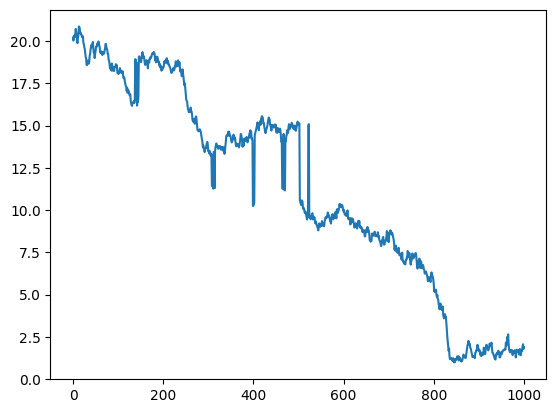

In [23]:
i=min_nrg_traj
print(rms_bybatch[:,i].min())
print(rms_bybatch[:,i].argmin())
plt.plot(rms_bybatch[:,i])

Text(0, 0.5, 'Model Energy')

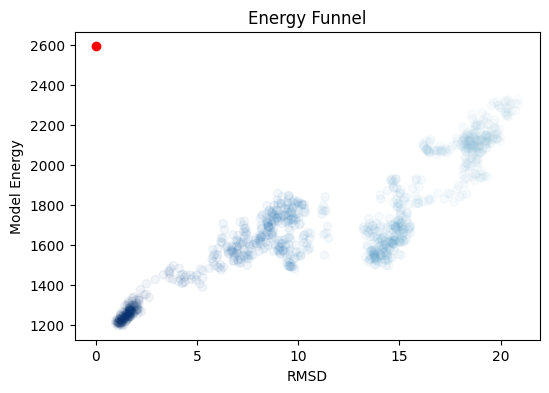

In [24]:
i = min_nrg_traj
end = -1
plt.figure(figsize=(6, 4))
plt.scatter(rms_bybatch[:end,i].numpy(), nrg_bybatch[:end,i].numpy(), alpha=0.05, c=-rms_bybatch[:end,i].numpy(), cmap=truncate_cmap("Blues", minval=0.35))
plt.scatter(np.zeros(1), native_energy.numpy().mean(), color='red')
plt.title("Energy Funnel")
plt.xlabel("RMSD")
plt.ylabel("Model Energy")

In [26]:
# calculate contacts 

ca_pos = atom_positions[...,1,:]
ind = torch.arange(ca_pos.shape[0])

contacts = torch.logical_and(torch.norm(ca_pos.unsqueeze(0) - ca_pos.unsqueeze(1), dim=-1) < 10, torch.abs(ind.unsqueeze(0) - ind.unsqueeze(1)) >= 7)
ca_traj = tseries[...,1,:] 

tseries_contacts = (torch.norm(ca_traj.unsqueeze(2) - ca_traj.unsqueeze(3), dim=-1) < 10).to(torch.float) * (torch.abs(ind.unsqueeze(0) - ind.unsqueeze(1)) >= 7)

In [27]:
# compute the contact presence rate

import numpy as np

HIGH = 10
LOW = 4

def find_threshold_transitions(X):
    T, N = X.shape

    # Regime masks
    high = X > HIGH
    low  = X < LOW

    # Detect entries and exits
    enter_high = np.vstack([high[0:1],  high[1:] & ~high[:-1]])
    exit_high  = np.vstack([np.zeros((1,high.shape[1]), dtype=bool), ~high[1:] & high[:-1]])

    enter_low  = np.vstack([low[0:1],   low[1:] & ~low[:-1]])
    exit_low   = np.vstack([np.zeros((1,high.shape[1]), dtype=bool),  ~low[1:] & low[:-1]])

    hi_to_lo = []
    lo_to_hi = []

    for col in range(N):

        # Collect event times and labels
        # type codes:
        # 0 = exit_high
        # 1 = enter_low
        # 2 = exit_low
        # 3 = enter_high

        times = np.concatenate([
            np.where(exit_high[:, col])[0],
            np.where(enter_low[:, col])[0],
            np.where(exit_low[:, col])[0],
            np.where(enter_high[:, col])[0],
        ])

        types = np.concatenate([
            np.zeros(np.sum(exit_high[:, col]), dtype=int),
            np.ones(np.sum(enter_low[:, col]), dtype=int),
            np.full(np.sum(exit_low[:, col]), 2, dtype=int),
            np.full(np.sum(enter_high[:, col]), 3, dtype=int),
        ])

        if len(times) == 0:
            continue

        # Sort events by time
        order = np.argsort(times)
        times = times[order]
        types = types[order]

        # Look for consecutive valid pairs
        for i in range(len(times) - 1):

            t1, t2 = times[i], times[i + 1]
            e1, e2 = types[i], types[i + 1]

            # exit_high -> enter_low
            if e1 == 0 and e2 == 1:
                hi_to_lo.append([t1, t2, col])

            # exit_low -> enter_high
            if e1 == 2 and e2 == 3:
                lo_to_hi.append([t1, t2, col])


    return (
        np.array(hi_to_lo, dtype=int),
        np.array(lo_to_hi, dtype=int)
    )


hi_to_lo, lo_to_hi = find_threshold_transitions(rms_bybatch.numpy())

torch.Size([10231, 56, 56])


/tmp/ipykernel_314991/857226585.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(s, e)


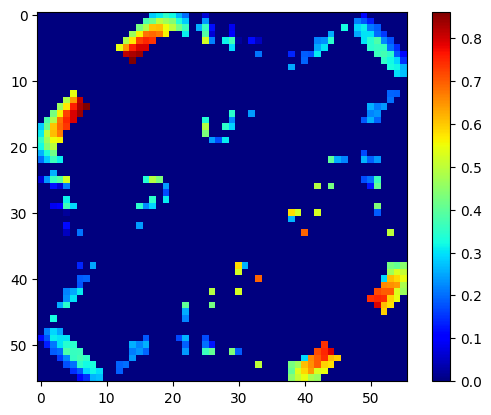

In [28]:
def extract_transition_values(X, transitions):
    if len(transitions) == 0:
        return np.array([])

    t_idx = np.concatenate([
        np.arange(s, e)
        for s, e, _ in transitions
    ])
    c_idx = np.concatenate([
        np.full(e - s, c)
        for s, e, c in transitions
    ])

    return X[t_idx, c_idx]

transition_contacts = extract_transition_values(tseries_contacts, torch.cat([torch.tensor(hi_to_lo), torch.tensor(lo_to_hi)]))

print(transition_contacts.shape)

mean_con = transition_contacts.mean(dim=0) * contacts
plt.imshow(mean_con, cmap='jet')

plt.colorbar()